"""
ADAPTIVE STRATEGY SIMULATION & PERFORMANCE ANALYSIS
---------------------------------------------------
This notebook evaluates trading strategies using either Oracle (Target) 
or Predictive (ML) signals. Key features include:

1. ORACLE GENERATION: Identifies ideal up-swings using future-peeking logic.
2. ACTION FILTERING: Applies RSI, ADX, and VWAP filters to signals.
3. BACKTESTING: Simulates execution including fees, spreads, and regulatory costs.
4. DIAGNOSTICS: Visualizes trade entries/exits against indicators and signal thresholds.
"""

In [6]:
%matplotlib inline
%reset -f

import gc, torch, importlib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from libs import preps, plots, params, feats, strats

# Sync all logic and Trial 340 parameters
importlib.reload(preps)
importlib.reload(plots)
importlib.reload(params)
importlib.reload(feats)
importlib.reload(strats)

pd.set_option('display.max_columns', None)
col_signal = params.col_signal_tick 
ticker = params.ticker

# Memory Cleanup
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()



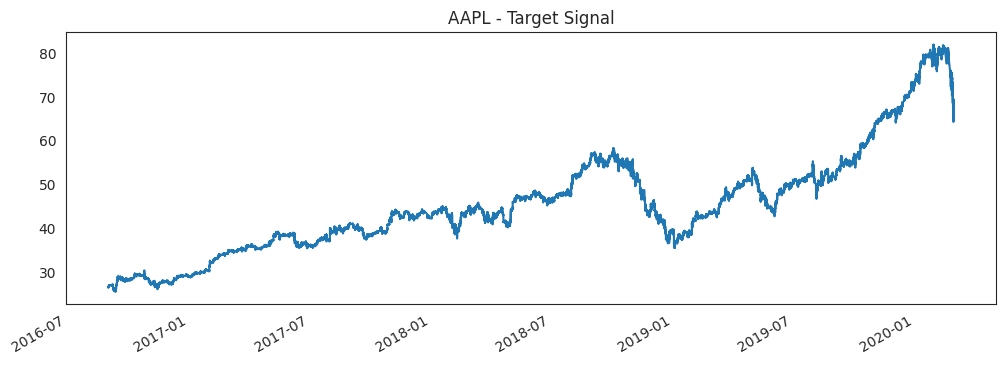

In [7]:
# Data Loading 

plt.figure(figsize=(12, 4))

if col_signal == "pred_signal":
    df = pd.read_parquet(params.pred_trainval_pqt)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df[(df.index >= params.start_date_sim) & (df.index < params.end_date_sim)]
    if 'close_raw' in df.columns: df.close_raw.plot(title=f"{ticker} - ML Signal")
else: # "targ_signal" or any indicator signal
    df = pd.read_parquet(params.indunsc_parquet)   
    df.index = pd.to_datetime(df.index).tz_localize(None) 
    df = df[(df.index >= params.start_date_sim) & (df.index < params.end_date_sim)]
    df.close.plot(title=f"{ticker} - Target Signal")

plt.show()

In [8]:
# importlib.reload(preps) ########################################

sign_thresh = params.sign_thresh_tick
thresh_mode = params.thresh_mode_tick

# Instantly resolve to a float if numeric, eliminating the extra variable
if thresh_mode == "numeric":
    thresh_mode = params.thresh_mode_num_tick

# Safe check for strings before using .startswith
thresh_window = params.thresh_window_tick if isinstance(thresh_mode, str) and thresh_mode.startswith("roll") else None

# Generate the Future Oracle (Target) if requested
if col_signal == 'targ_signal':
    print('Generating Target Oracle Signal...')
    df = preps.build_signal_per_day(
        df              = df.copy(), 
        min_prof_thr    = params.min_prof_thr_tick, 
        max_down_prop   = params.max_down_prop_tick, 
        gain_tightfact  = params.gain_tightfact_tick,
        tau_time        = params.tau_time_tick, 
        tau_dur         = params.tau_dur_tick, 
        col_close       = "close"
    )

# Apply statistical thresholds to the signal
if col_signal in ('targ_signal', 'pred_signal'): 
    print('computing threshold...')
    df = preps.apply_thresholds_per_day(
        df              = df, 
        col_signal      = col_signal, 
        thresh_mode     = thresh_mode, 
        thresh_window   = thresh_window, 
        # thresh_mode_num = thresh_mode_num
    )

# Only check for NaNs if the threshold is a column in the dataframe
if isinstance(sign_thresh, str): 
    if df[sign_thresh].isna().any(): 
        raise ValueError(f"Threshold column '{sign_thresh}' contains NaNs — fill or re-run apply_thresholds_per_day.")

if col_signal == "pred_signal":
    raw_ext = "_raw" # the raw indicators are saved with the '_raw' extension in the predictions df
    targ_signal = 'targ_signal' # used to plot the target signal along with the predicted signal
else:
    raw_ext = ''
    targ_signal = None

# Reset ONCE for the whole period (Matches Optuna start_ask exactly)
first_day = df.index.normalize().min()
start_ask = df.loc[df.index.normalize() == first_day, "ask"].iloc[0]
strats.reset_globals(start_ask)

sim_results = {}
groups = df.groupby(df.index.normalize())
total_days = df.index.normalize().nunique()

raw_atr = params.col_atr_tick + raw_ext
raw_adx = params.col_adx_tick + raw_ext
raw_rsi = params.col_rsi_tick + raw_ext
raw_vwap = params.col_vwap_tick + raw_ext
raw_close = 'close' + raw_ext

for day, df_day_sim in tqdm(groups, desc=f"Backtesting: {col_signal}"):

    df_actions = strats.generate_actions(
        df              = df_day_sim,
        col_signal      = col_signal,
        sign_thresh     = sign_thresh,
        col_atr         = raw_atr,
        col_adx         = raw_adx,
        col_rsi         = raw_rsi,
        col_vwap        = raw_vwap,
        col_close       = raw_close,
        buy_factor      = params.buy_factor_tick,
        sell_factor     = params.sell_factor_tick,
        rsi_min_thresh  = params.rsi_min_thresh_tick,
        rsi_max_thresh  = params.rsi_max_thresh_tick,
        atr_mult        = params.atr_mult_tick,
        vwap_atr_mult   = params.vwap_atr_mult_tick,
        adx_thresh      = params.adx_thresh_tick,
        trailstop_pct   = params.trailstop_pct_tick,
    )
    
    sim_results.update(
        strats.simulate_trading(
            day         = day,
            df          = df_actions
        )
    )

print("Loop finished. Days simulated:", len(sim_results))

df

Backtesting: cci_20:   0%|          | 0/878 [00:00<?, ?it/s]

Loop finished. Days simulated: 878


,open,high,low,close,volume,trade_count,vwap,ask,bid,ret,log_ret,sma_5,sma_pct_5,sma_9,sma_pct_9,sma_21,sma_pct_21,sma_50,sma_pct_50,sma_100,sma_pct_100,ema_5,ema_9,ema_13,ema_21,ema_50,roc_5,roc_10,roc_21,body,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,macd_line_6_13_5,macd_signal_6_13_5,macd_diff_6_13_5,macd_line_12_26_9,macd_signal_12_26_9,macd_diff_12_26_9,atr_7,atr_pct_7,atr_14,atr_pct_14,atr_21,atr_pct_21,atr_28,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_lband_20_2p0,bb_hband_20_2p0,bb_w_20_2p0,bb_lband_20_3p0,bb_hband_20_3p0,bb_w_20_3p0,bb_lband_50_2p0,bb_hband_50_2p0,bb_w_50_2p0,obv,vol_spike_7,vol_spike_14,vol_spike_28,rolling_max_close_100,rolling_min_close_100,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_h_20,donch_l_20,donch_w_20,donch_h_55,donch_l_55,donch_w_55,roll_vwap_20,roll_vwap_50,slope_close_20,slope_close_50,kc_mid_20_20_1.5,kc_l_20_20_1.5,kc_h_20_20_1.5,kc_w_20_20_1.5,kc_mid_20_20_2.0,kc_l_20_20_2.0,kc_h_20_20_2.0,kc_w_20_20_2.0,vwap_ohlc_close_session
2016-09-01 07:43:00,26.567500,26.567500,26.567500,26.567500,400.000000,1.0,106.270000,26.572825,26.562175,0.002547,0.002544,26.513500,0.002037,26.507917,0.002248,26.508671,0.002219,26.509184,0.002200,26.511912,0.002097,26.522714,26.514628,26.511819,26.509984,26.509716,0.002547,0.002358,0.002153,0.00000,0.000000,0.000000,0.0,0.000000,96.100648,91.731616,89.132611,87.163155,0.007863,0.001180,0.006683,0.002684,-0.001149,0.003833,0.012425,0.000468,0.007272,0.000274,0.005287,0.000199,0.004309,0.000162,77.847053,3.158700,79.529484,67.333142,6.068881,59.711121,62.487551,7.607933,47.758956,58.258769,8.516388,35.280109,26.479926,26.537199,0.002161,26.465608,26.551517,0.003241,26.490969,26.527400,0.001374,1.889951e+09,0.074066,0.074065,0.117020,26.567500,26.5000,0.000000,0.002541,20868.000000,787.185256,-15838.000000,-597.464891,0.000561,0.000322,0.333333,0.111111,0.333333,0.111111,459.697332,500.000000,0.530300,5.043771,-0.941806,-0.901572,26.567500,26.5000,0.002541,26.567500,26.50,0.002541,26.503302,26.505749,0.000156,-0.000034,26.510100,26.501867,26.518332,0.000621,26.510100,26.499123,26.521076,0.000828,26.567500
2016-09-01 07:44:00,26.570833,26.570833,26.570833,26.570833,533.333333,1.0,106.283333,26.576158,26.565508,0.000125,0.000125,26.527667,0.001627,26.515509,0.002086,26.511528,0.002237,26.510386,0.002280,26.512400,0.002204,26.538754,26.525869,26.520250,26.515516,26.512113,0.002673,0.002531,0.002263,0.00000,0.000000,0.000000,0.0,0.000000,96.304618,92.110588,89.600533,87.692162,0.014047,0.005469,0.008578,0.007154,0.000512,0.006642,0.011126,0.000419,0.006991,0.000263,0.005194,0.000195,0.004274,0.000161,78.795162,3.023513,81.398020,68.445692,5.862190,61.461890,63.634036,7.375413,49.257432,59.421444,8.279170,36.718027,26.472062,26.551021,0.002978,26.452323,26.570761,0.004467,26.485289,26.535484,0.001893,1.889952e+09,0.124989,0.102224,0.158287,26.570833,26.5000,0.000000,0.002666,29869.333333,1126.304732,-16504.666667,-622.546796,0.000560,0.000323,0.666667,0.333333,0.666667,0.333333,240.255704,343.070611,1.280933,4.394688,-0.932459,-0.907747,26.570833,26.5000,0.002666,26.570833,26.50,0.002666,26.503631,26.505931,0.001088,0.000115,26.515884,26.507813,26.523955,0.000609,26.515884,26.505123,26.526645,0.000812,26.569405
2016-09-01 07:45:00,26.574167,26.574167,26.574167,26.574167,666.666667,1.0,106.296667,26.579492,26.568842,0.000125,0.000125,26.542500,0.001193,26.523611,0.001906,26.514524,0.002249,26.511656,0.002358,26.512923,0.002310,26.550558,26.535529,26.527952,26.520848,26.514546,0.002799,0.002704,0.002373,0.00000,0.000000,0.000000,0.0,0.000000,96.517165,92.481688,90.050360,88.196595,0.017736,0.009558,0.008178,0.010841,0.002577,0.008263,0.010013,0.000377,0.006730,0.000253,0.005105,0.000192,0.004240,0.000

No simulation data for 2022-01
Overall Summary (2016-09-01 = 26.573 → 2020-02-28 = 68.861)
Num. trading days: 878
Trades Count: 515
Initial capital: 100000.000

One-Time B&H gain: 157209.949 | final: 257209.949 | PnL%: 157.21%
Sum Strategy gain: 102221.267 | final: 202221.267 | PnL%: 102.22%
Sum Intraday gain: -37075.152 | final: 62924.848 | PnL%: -37.08%

One-Time B&H gain per day: 179.0546
Strategy gain per day: 116.4251
Strategy gain per trade: 198.4879


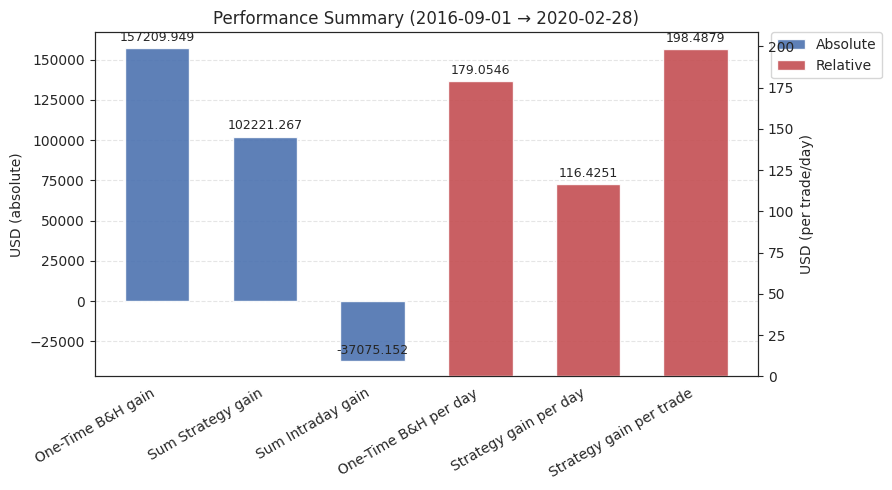

Rolling monthly summary (each metric carries its own capital forward):

Monthly Summary 2016-09 (2016-09-01 = 26.573 → 2016-09-30 = 28.247)
Num. trading days: 21  Trades Count: 11
One-Time B&H gain: 6196.152 | start: 100000.000 | final: 106196.152 | PnL%: 6.20%
Sum Strategy gain: 60.264 | start: 100000.000 | final: 100060.264 | PnL%: 0.06%
Sum Intraday gain: -4725.619 | start: 100000.000 | final: 95274.381 | PnL%: -4.73%

Monthly Summary 2016-10 (2016-10-03 = 28.247 → 2016-10-31 = 28.379)
Num. trading days: 21  Trades Count: 19
One-Time B&H gain: 559.266 | start: 106196.152 | final: 106755.418 | PnL%: 0.53%
Sum Strategy gain: 4740.826 | start: 100060.264 | final: 104801.090 | PnL%: 4.74%
Sum Intraday gain: -3912.252 | start: 95274.381 | final: 91362.129 | PnL%: -4.11%

Monthly Summary 2016-11 (2016-11-01 = 28.379 → 2016-11-30 = 27.657)
Num. trading days: 21  Trades Count: 26
One-Time B&H gain: -2869.240 | start: 106755.418 | final: 103886.178 | PnL%: -2.69%
Sum Strategy gain: 1822.943 

In [9]:
# --- Monthly Visual Results ---

# Convert month string (YYYY-MM) to components
year_val, month_val = map(int, params.month_to_check.split("-"))
dates_in_month = [d for d in sim_results if d.year == year_val and d.month == month_val]

if not dates_in_month:
    print(f"No simulation data for {params.month_to_check}")
else:
    for date in sorted(dates_in_month):
        df_p, trades, stats = sim_results[date]
        
        # Plot indicators and trade entries/exits
        plots.plot_trades(
            df                 = df_p, 
            col_signal1        = col_signal, 
            col_signal2        = 'targ_signal' if col_signal == "pred_signal" else None,
            sign_thresh        = sign_thresh, 
            col_close          = raw_close, 
            axis_sig_thresh    = 'second',
            features           = [params.col_atr_tick + raw_ext, 
                                  params.col_adx_tick + raw_ext, 
                                  params.col_rsi_tick + raw_ext],
            autoscale          = False
        )

        print(f"\n{' ' * 50}******* Performance for {date.strftime('%Y-%m-%d')} *******\n")
        for k,v in stats.items(): # Print stats dict for each date nicely
            print(f"{k}:\n" + "\n".join("  "+L for L in (v if isinstance(v,list) else str(v).splitlines())))
        print("\n" + "="*160 + "\n")

# Final calculation of aggregate performance metrics
strats.aggregate_performance(df=df, sim_results=sim_results)

In [10]:
# # propose adjusted parameters ranges for next optuna run

# from libs import opts
# import importlib
# importlib.reload(opts)

# new_ranges = opts.propose_ranges_from_top(
#     csv_path="optuna_results/AAPL_360.1988_pred_IND.csv",
#     top_n=30,
#     spread=1,
#     agg="median",
#     cat_top_k=3,
# )

# new_ranges